# Libs & Data

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/Avvonna/Other/refs/heads/main/CO2%20Emissions_Canada.csv")
print(f"Размерность датасета: {df.shape}")

Размерность датасета: (7385, 12)


In [ ]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


# Корреляция

**Разогрев:**
- *Что это вообще такое?*
- *Зачем нужен этот статистический показатель?*
- *Какие виды корреляции вам известны?*

## Корреляция Пирсона (Pearson)

### Формула

$$
r = \frac{\sum_{i=1}^n (X - \bar{X})(Y - \bar{Y})}{\sqrt{\sum_{i=1}^n (X - \bar{X})^2 (Y - \bar{Y})^2}}
= \frac{\text{cov}(X, Y)}{S_X S_Y}
$$

где:

$\bar{X}, \bar{Y} - $ средние значения переменных  
$S_X, S_Y - $ выборочные стандартные отклонения  
$\text{cov}(X, Y) - $ выборочная ковариация переменных

![pearson.png](https://raw.githubusercontent.com/Avvonna/Other/refs/heads/main/pearson.png)

### Пример

| Студент | Тест 1 | Тест 2 |
|:-------:|:------:|:------:|
| A       | $85$   | $82$   |
| B       | $70$   | $65$   |
| C       | $70$   | $75$   |
| D       | $90$   | $95$   |
| E       | $65$   | $68$   |

**Значение коэффициента:**

$\bar{X} = \frac{85+70+70+90+65}{5} = 76$

$\bar{Y} = \frac{82+65+75+95+68}{5} = 77$

$\text{cov}(X, Y) = \frac{1}{5-1}\Big[ (85-76)(82-77) + (70-76)(65-77) + (70-76)(75-77) + (90-76)(95-77) + (65-76)(68-77) \Big] = \frac{480}{4} = 120$

$S_X = \sqrt{\frac{(85-76)^2 + (70-76)^2 + (70-76)^2 + (90-76)^2 + (65-76)^2}{5-1}} = \sqrt{\frac{470}{4}} = \sqrt{117.5} \approx 10.840$

$S_Y = \sqrt{\frac{(82-77)^2 + (65-77)^2 + (75-77)^2 + (95-77)^2 + (68-77)^2}{5-1}} = \sqrt{\frac{578}{4}} = \sqrt{144.5} \approx 12.021$

$r = \frac{\text{cov}(X, Y)}{S_X S_Y} \approx \frac{120}{10.840 \times 12.021} \approx 0.921$

Проверим с использованием пакета `scipy`

In [ ]:
from scipy.stats import pearsonr


Test_1 = [85, 70, 70, 90, 65]
Test_2 = [82, 65, 75, 95, 68]

r_pearson = pearsonr(Test_1, Test_2)[0]
print(f"Коэфф. корреляции Пирсона: {r_pearson:.3f}")

Коэфф. корреляции Пирсона: 0.921


> **На подумать**: геометрическая интерпретация коэффициента корреляции или почему $ -1 < r < 1 $

<details>

<summary>Пояснение</summary>

Если рассмотреть два вектора $\mathbf{X} = (X - \bar{X})$ и $\mathbf{Y} = (Y - \bar{Y})$ то коэффициент корреляции можно интерпретировать как косинус угла между этими векторами, поскольку:

$\mathbf{X} \cdot \mathbf{Y} = \sum_{i=1}^n (X_i - \bar{X})(Y_i - \bar{Y})$ - **скалярное произведение двух векторов**

$\|\mathbf{X}\| = \sqrt{\sum_{i=1}^n (X_i - \bar{X})^2}$ и $\|\mathbf{Y}\| = \sqrt{\sum_{i=1}^n (Y_i - \bar{Y})^2}$ - **нормы векторов, их длины**

Косинус угла между двумя векторами вычисляется как:
$$\cos \theta = \frac{\mathbf{X} \cdot \mathbf{Y}}{\|\mathbf{X}\| \|\mathbf{Y}\|}$$

Подставляя выражения для скалярного произведения и норм, получаем формулу для коэффициента корреляции Пирсона:

$$ r = \frac{\sum_{i=1}^n (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^n (X_i - \bar{X})^2} \cdot \sqrt{\sum_{i=1}^n (Y_i - \bar{Y})^2}}$$

- Если $ \theta = 0^\circ $: вектора направлены в одну сторону, их связь максимальна, и $ r = 1 $.  
- Если $ \theta = 180^\circ $: вектора направлены в противоположные стороны, связь отрицательна, и $ r = -1 $.  
- Если $ \theta = 90^\circ $: вектора ортогональны, и $ r = 0 $, что означает отсутствие линейной зависимости.

</details>

### Как рассчитать в Pandas?

- Между двумя переменными в датасете:  
    Например, между `Fuel Consumption Comb (mpg)` и `CO2 Emissions(g/km)`

In [ ]:
df["Fuel Consumption Comb (mpg)"].corr(df["CO2 Emissions(g/km)"]).round(2)

-0.91

- Между всеми числовыми переменными в датасете (**корреляционная матрица**):

In [ ]:
df.corr(numeric_only=True).round(2)

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
Engine Size(L),1.00,0.93,0.83,0.76,0.82,-0.76,0.85
Cylinders,0.93,1.00,0.80,0.72,0.78,-0.72,0.83
Fuel Consumption City (L/100 km),0.83,0.80,1.00,0.95,0.99,-0.93,0.92
Fuel Consumption Hwy (L/100 km),0.76,0.72,0.95,1.00,0.98,-0.89,0.88
Fuel Consumption Comb (L/100 km),0.82,0.78,0.99,0.98,1.00,-0.93,0.92
Fuel Consumption Comb (mpg),-0.76,-0.72,-0.93,-0.89,-0.93,1.00,-0.91
CO2 Emissions(g/km),0.85,0.83,0.92,0.88,0.92,-0.91,1.00


### Как лучше визуализировать?

- `heatmap` (из библиотеки `seaborn`)  
    - `data` - визуализируемая матрица
    - `cmap` - используемая палитра
    - `vmin`, `vmax` - значения, относительно которых строится палитра
    - `annot`, `fmt` - отвечают за наличие и формат подписей значений

<Axes: >

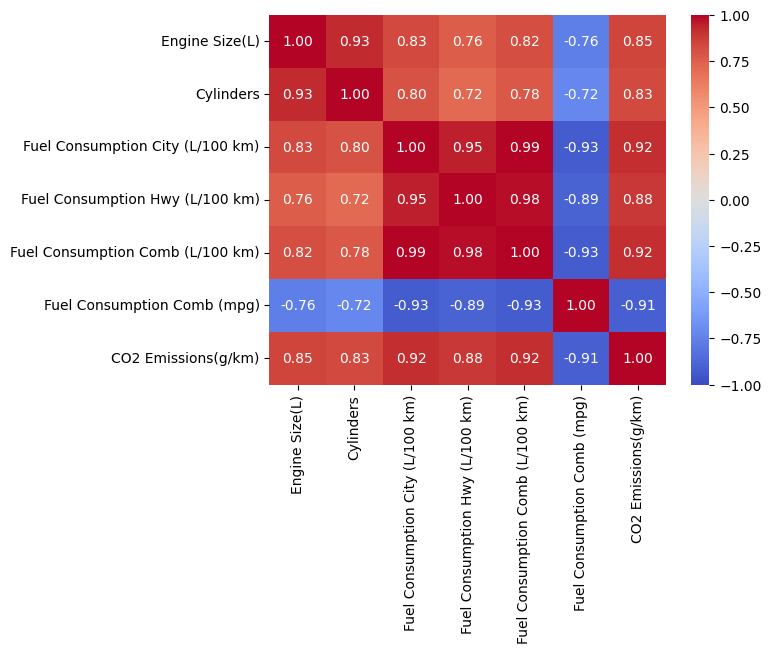

In [ ]:
sns.heatmap(
    data=df.corr(numeric_only=True),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
)


### Sidenote: свойства корреляционной матрицы


- На главной диагонали расположены $1$  
    Поскольку корреляция переменной самой с собой (**автокорреляция**) равна $1$

- Симметрична относительно главной диагонали  
    Поскольку $\text{cor}(X, Y) = \text{cor}(Y, X)$

## Корреляция Спирмена (Spearman)

### Формула

$$ r_s = \frac{\text{cov}(r_X,r_Y)}{S_{r_X} S_{r_Y}} $$

где:

$r_X,  r_Y$ - ранги переменных $X$ и $Y$  
$\text{cov}(r_X,  r_Y)$ - выборочная ковариация рангов  
$S_{r_X}, S_{r_Y}$ - выборочные стандартные отклонения рангов

**В случае отсутствия повторяющихся рангов** формула приобретает вид:

$$r_s = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$

где:

$d_i$ - разница рангов между значениями $x_i$ и $y_i$  
$n$ - число наблюдений


<details>

<summary>Почему?..</summary>

При отсутствии повторяющихся рангов переменные $x_i$ и $y_i$ представляют собой уникальные значения $[1, 2, 3, \dots, n]$.  
Это гарантирует, что средний ранг каждой переменной равен $\bar{r} = \frac{n+1}{2}$.  
Заметим, что сумма рангов: $\sum r_i = \frac{n(n+1)}{2}$,
а сумма квадратов рангов: $\sum r_i^2 = \frac{n(n+1)(2n+1)}{6}$

Пусть разность рангов: $d_i = r_{X_i} - r_{Y_i}$  
Выразим $\text{cov}(r_X, r_Y)$ через $d_i$

$$ \sum d_i^2 = \sum r_{X_i}^2 + \sum r_{Y_i}^2 - 2 \sum (r_{X_i} \cdot r_{Y_i})$$

Отсюда:
$$
\sum (r_{X_i} \cdot r_{Y_i})
= \frac{ \sum r_{X_i}^2 + \sum r_{Y_i}^2 - \sum d_i^2}{2}
= \sum r_i^2 - \frac{\sum d_i^2}{2}
= \frac{n(n+1)(2n+1)}{6} - \frac{\sum d_i^2}{2}
$$

Тогда:

$$
\text{cov}(r_X, r_Y)
= \frac{1}{n}\sum (r_{X_i} \cdot r_{Y_i}) - \bar{r}^2
= \frac{1}{n} \left( \frac{n(n+1)(2n+1)}{6} - \frac{\sum d_i^2}{2} \right) - (\frac{n+1}{2})^2
= \frac{n^2-1}{12} - \frac{\sum d_i^2}{2n}
$$

Дисперсия рангов ($\sigma^2$) одинакова для обеих переменных и равна:

$$
\text{var}(r)
= \frac{1}{n}\sum r_i^2 - \bar{r}^2
= \frac{n(n+1)(2n+1)}{6n} - (\frac{n+1}{2})^2
= \frac{n^2-1}{12}
$$

Отсюда следует:

$$
r_s = \frac{\text{cov}(r_X, r_Y)}{\sigma_{r_X} \sigma_{r_Y}}
= \frac{\text{cov}(r_X, r_Y)}{\text{var}(r)} = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}
$$

</details>

### Более понятными словами

Тот же самый коэффициент Пирсона, но перед его применением переменные ранжируются

### Пример

| Студент | Тест 1 | Тест 2 |
|:-------:|:------:|:------:|
| A       | $85$   | $82$   |
| B       | $70$   | $65$   |
| C       | $70$   | $75$   |
| D       | $90$   | $95$   |
| E       | $65$   | $68$   |

**Ранжирование:**

- Тест 1: $[65, \color{red}{70}, \color{red}{70}, 85, 90]$

- Тест 2: $[65, 68, 75, 82, 95]$


| Студент | Тест 1 | Тест 2 |
|:-------:|:------:|:------:|
| A       | $4$    | $4$    |
| B       | $\color{red}{2.5}$  | $1$    |
| C       | $\color{red}{2.5}$  | $3$    |
| D       | $5$    | $5$    |
| E       | $1$    | $2$    |

**Значение коэффициента:**

Поскольку у нас есть дублирующиеся ранги, воспользуемся общей формулой

$\bar{r}_X = \frac{15}{5} = 3$

$\bar{r}_Y = \frac{15}{5} = 3$

$\text{cov}(r_X, r_Y) = \frac{1}{5-1}\Big[ (4-3)(4-3) + (2.5-3)(1-3) + (2.5-3)(3-3) + (5-3)(5-3) + (1-3)(2-3) \Big] = \frac{8}{4} = 2$

$S_{r_X} = \sqrt{\frac{(4-3)^2 + (2.5-3)^2 + (2.5-3)^2 + (5-3)^2 + (1-3)^2}{5-1}} = \sqrt{\frac{9.5}{4}} = \sqrt{2.375} \approx 1.541$

$S_{r_Y} = \sqrt{\frac{(4-3)^2 + (1-3)^2 + (3-3)^2 + (5-3)^2 + (2-3)^2}{5-1}} = \sqrt{\frac{10}{4}} = \sqrt{2.5} \approx 1.581$

$r_s = \frac{\text{cov}(r_X, r_Y)}{S_{r_X} S_{r_Y}} \approx \frac{8}{1.541 \times 1.581} \approx 0.821$

Проверим с использованием пакета `scipy`

In [ ]:
from scipy.stats import spearmanr


r_spearman = spearmanr(Test_1, Test_2)[0]
print(f"Коэфф. корреляции Спирмена: {r_spearman:.3f}")

Коэфф. корреляции Спирмена: 0.821


### Как рассчитать в Pandas?

Используемые функции аналогичны, необходимо указывать аргумент `method = "spearman"`

```python
df["col_1"].corr(df["col_2"], method="spearman")
# или
df.corr(method="spearman", numeric_only=True)
```

## Корреляция Кендалла (Kendall)

### Формула ($\tau_b$)

$$\tau_b = \frac{N_C - N_D}{\sqrt{(N_0 - N_1)(N_0 - N_2)}}$$

где:

$N_C$ - количество согласованных (конкордантных) пар  
$N_D$ - количество несогласованных (дискордантных) пар  
$N_0 = \frac{N(N-1)}{2}$ - количество всех пар ($N$ - размер выборки)  
$N_1$ - сумма связанных рангов по первой переменной  
$N_2$ - сумма связанных рангов по второй переменной

### Более понятными словами


Смотрим на каждую пару наблюдений по двум переменным (всего пар $N_0$):

- Если обе переменные изменяются в одном направлении $(X_\uparrow, Y_\uparrow$ или $X_\downarrow, Y_\downarrow)$,
считаем, что такая пара согласована (конкордантна), увеличиваем $N_C$
- Если переменные двигаются в разных направлениях $(X_\uparrow, Y_\downarrow$ или $X_\downarrow, Y_\uparrow)$,
считаем, что такая пара несогласована (дискордантна), увеличиваем $N_D$
- Если какая-то переменная остается неизменной, увеличиваем $N_1$ или $N_2$ (или оба значения) соответственно

### Пример

| Студент | Тест 1 | Тест 2 |
|:-------:|:------:|:------:|
| A       | $85$   | $82$   |
| B       | $70$   | $65$   |
| C       | $70$   | $75$   |
| D       | $90$   | $95$   |
| E       | $65$   | $68$   |

**Анализ пар:**

| Пара   | Тест 1      | Тест 2      | Меняем |
|:------:|:-----------:|:-----------:|:------:|
| (A, B) | $$85\to70$$ | $$82\to65$$ | $$N_C$$  |
| (A, C) | $$85 \to 70$$ | $$82 \to 75$$ | $$N_C$$  |
| (A, D) | $$85 \to 90$$ | $$82 \to 95$$ | $$N_C$$  |
| (A, E) | $$85 \to 65$$ | $$82 \to 68$$ | $$N_C$$  |
| (B, C) | $$\color{green}{70 \to 70}$$ | $$65 \to 75$$ | $$\color{green}{N_1}$$     |
| (B, D) | $$70 \to 90$$ | $$65 \to 95$$ | $$N_C$$  |
| (B, E) | $$\color{red}{70 \to 65}$$ | $$\color{red}{65 \to 68}$$ | $$\color{red}{N_D}$$     |
| (C, D) | $$70 \to 90$$ | $$75 \to 95$$ | $$N_C$$  |
| (C, E) | $$70 \to 65$$ | $$75 \to 68$$ | $$N_C$$  |
| (D, E) | $$90 \to 65$$ | $$95 \to 68$$ | $$N_C$$  |


$N_C = 8, N_D = 1, N_0 = 10, N_1 = 1, N_2 = 0$

**Значение коэффициента:**

$\tau_b = \frac{8 - 1}{\sqrt{(10 - 1)(10 - 0)}} = \frac{7}{\sqrt{90}} \approx 0.738$

Проверим с использованием пакета `scipy`

In [ ]:
from scipy.stats import kendalltau


r_kendall = kendalltau(Test_1, Test_2)[0]
print(f"Коэфф. корреляции Кендалла: {r_kendall:.3f}")

Коэфф. корреляции Кендалла: 0.738


### Как рассчитать в Pandas?

Используемые функции аналогичны, необходимо указывать аргумент `method = "kendall"`

```python
df["col_1"].corr(df["col_2"], method="kendall")
# или
df.corr(method="kendall", numeric_only=True)
```

## Интерпретация полученных коэффициентов

**ВАЖНО: Корреляция не то же самое, что причинно-следственная связь!**  
Даже если между двумя переменными существует сильная корреляция, это не обязательно означает,  
что изменение одной переменной вызывает изменение другой переменной.

В целом, все коэффициенты корреляции оценивают степень взаимосвязи переменных.

Существенная разница состоит в том, что:
- **Пирсон** учитывает только линейные зависимости
- **Спирмен** и **Кендалл** — монотонные.  

Значения коэффициентов интерпретируются следующим образом:

- $r > 0$: положительная (прямая) связь в рамках анализируемого типа зависимости.
- $r < 0$: отрицательная (обратная) связь в рамках анализируемого типа зависимости.
- $r = 0$: отсутствие зависимости в рамках анализируемого типа зависимости.

Сила корреляции определяется по абсолютному значению коэффициента, вне зависимости от знака:

- $|r| < 0.3$: слабая корреляция
- $0.3 \leq |r| < 0.7$: умеренная корреляция
- $|r| \geq 0.7$: сильная корреляция


## Когда какой коэффициент использовать?

**Коэффициент Пирсона** - основной метод для большинства задач
- Когда на графике видна примерно линейная связь между переменными
- Для количественных данных (рост, вес, возраст, доход и т.д.)
- При необходимости дальнейшего использования в линейной регрессии
- Не рекомендуется при явно нелинейных связях или серьёзных выбросах в данных

**Коэффициент Спирмена** - более устойчивый, но менее мощный метод
- При наличии выбросов в данных (например, экстремальные значения в экономических показателях)
- Для порядковых данных (опросы по шкале Ликерта, уровни образования, звания и пр.)
- Когда связь монотонная, но не линейная (например, экспоненциальная или степенная)
- Для проверки надёжности результатов Пирсона (если коэффициенты сильно различаются, нужен дополнительный анализ данных)

**Коэффициент Кендалла** - для специальных случаев
- При малых выборках (n < 30) с большим количеством повторяющихся значений
- Для оценки согласованности экспертных мнений (например, оценки жюри)
- В задачах ранжирования (сравнение результатов разных методов ранжирования)
- Когда нужна более консервативная оценка связи (значения обычно меньше Спирмена)

**На практике:**

Начните с визуализации и постройте диаграммы рассеяния (scatter plots) для изучения структуры данных. Определите тип связи, наличие выбросов.  
\* Если связь явно нелинейная, рассмотрите возможность преобразования данных (например, логарифмирование, возведение в степень или стандартизацию), чтобы приблизить зависимость к линейной и улучшить интерпретируемость.

- Для количественных переменных со связью, близкой к линейной, без значимых выбросов используйте коэффициент Пирсона.
- Для порядковых данных, а также для данных с нелинейными зависимостями или выбросами — коэффициент Спирмена.
- При анализе малых выборок с повторяющимися рангами — коэффициент Кендалла.


## Универсальный способ оценки корреляций (phik - $\phi_K$)

Не углубляясь в достаточно сложный процесс, скажем, что в основе данного коэффициента лежит $\chi^2$ статистика,  
которая описывает отклонение реальных частот от ожидаемых в таблице сопряженности.

<details>

<summary>Подробнее про хи-квадрат...</summary>

Тест $\chi^2$ (хи-квадрат) является статистическим методом проверки гипотез о взаимосвязи между двумя категориальными переменными.  
Его суть заключается в сравнении наблюдаемых частот событий с ожидаемыми частотами, предполагая отсутствие зависимости между переменными.

Основные шаги проведения теста включают:

1. **Составление таблицы сопряженности.**  
   Для анализа взаимосвязи переменные представляют в виде таблицы, где строки и столбцы соответствуют категориям переменных. На пересечении указаны наблюдаемые частоты.

2. **Расчет ожидаемых частот.**  
   Ожидаемые частоты вычисляются по формуле:  
   $$ E_{ij} = \frac{R_i}{N} \cdot \frac{C_j}{N} \cdot N= \frac{R_i \cdot C_j}{N}$$  

   где  
     
   $R_i$ — сумма по строке $i$,  
   $C_j$ — сумма по столбцу $j$,  
   $N$ — общая сумма частот.

3. **Вычисление статистики $\chi^2$.**  
   Разница между наблюдаемыми ($O_{ij}$) и ожидаемыми ($E_{ij}$) частотами оценивается через сумму:  
   $$\chi^2 = \sum_{i}\sum_{j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

4. **Сравнение с критическим значением.**  
   Полученное значение $\chi^2$ сравнивают с критическим из таблицы критических значений, где учитываются степень свободы  
   $df = (r-1)(c-1)$ и уровень значимости $\alpha$, обычно равный $0.05$.

Если $\chi^2$ превышает критическое значение, гипотеза о независимости отвергается, и делается вывод о наличии связи между переменными.

**Как это связано с оценкой силы взаимосвязи?**

Статистика $\chi^2$ указывает на наличие или отсутствие зависимости между переменными, но сама по себе не предоставляет информации о её силе.  
Для интерпретации силы связи используются производные показатели, такие как, например, коэффициент $\phi$ (Phi)

</details>


Для данного коэффициента нет возможности написать формулу в явном виде, а строгие выкладки выходят за рамки сложности и курса. Если интересно, источник: https://arxiv.org/pdf/1811.11440

### Как рассчитать в Pandas?

Используем библиотеку `phik` и функцию `phik_matrix`.  
Указывать `interval_cols` необязательно, но тогда алгоритм сам будет выбирать числовые переменные.

In [ ]:
!pip install phik --quiet

import phik

phik_corr_matrix = phik.phik_matrix(
    df.drop("Model", axis=1),  # Убираем столбец с названием модели
    interval_cols=[
        "Fuel Consumption City (L/100 km)",
        "Fuel Consumption Hwy (L/100 km)",
        "Fuel Consumption Comb (L/100 km)",
        "Fuel Consumption Comb (mpg)",
        "CO2 Emissions(g/km)",
    ],
)

phik_corr_matrix.round(2)

,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
Make,1.00,0.80,0.95,0.89,0.90,0.74,0.74,0.64,0.71,0.66,0.76
Vehicle Class,0.80,1.00,0.80,0.62,0.73,0.52,0.61,0.64,0.62,0.57,0.60
Engine Size(L),0.95,0.80,1.00,0.98,0.84,0.74,0.86,0.78,0.84,0.80,0.87
Cylinders,0.89,0.62,0.98,1.00,0.53,0.29,0.72,0.61,0.69,0.64,0.74
Transmission,0.90,0.73,0.84,0.53,1.00,0.62,0.61,0.58,0.61,0.62,0.60
Fuel Type,0.74,0.52,0.74,0.29,0.62,1.00,0.65,0.66,0.66,0.65,0.37
Fuel Consumption City (L/100 km),0.74,0.61,0.86,0.72,0.61,0.65,1.00,0.94,0.99,0.95,0.95
Fuel Consumption Hwy (L/100 km),0.64,0.64,0.78,0.61,0.58,0.66,0.94,1.00,0.97,0.92,0.90
Fuel Consumption Comb (L/100 km),0.71,0.62,0.84,0.69,0.61,0.66,0.99,0.97,1.00,0.96,0.95
Fuel Consumption Comb (mpg),0.66,0.57,0.80,0.64,0.62,0.65,0.95,0.92,0.96,1.00,0.93


<Axes: >

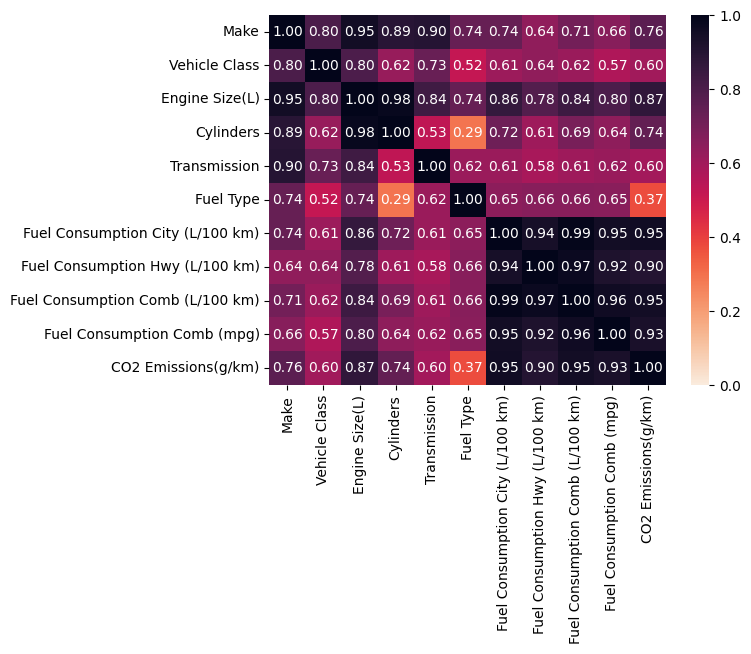

In [ ]:
sns.heatmap(
    data=phik_corr_matrix,
    cmap="rocket_r",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
)

Огромное преимущество данного подхода заключается в том, что нам не надо думать о типах данных -  
phik посчитает коэффициент корреляции между любыми переменными!

Это значительно упрощает анализ больших датасетов.

Существенное отличие состоит в том, что получаемый коэффициент находится в диапазоне от $0$ до $1$,  
обозначая соответственно полное отсутствие зависимости и полную зависимость между парой переменных.

## Сравнение коэффициентов корреляции

Для некоторых синтетических данных были посчитаны коэфициенты корреляции:

![dist.png](https://raw.githubusercontent.com/Avvonna/Other/refs/heads/main/dist_1.png)

**Для обсуждения:**

- Почему **Пирсон** дает плохие результаты в первом случае?
- Объясните, с чем связан больший коэффициент **Спирмена** по сравнению с **Пирсеном** на втором рисунке?
- Справляются ли коэффициенты корреляции с гетероскедастичностью ($3$ и $6$ рисунки)?

И еще немного сравнений на различного вида распределениях

![dist.png](https://raw.githubusercontent.com/Avvonna/Other/refs/heads/main/dist_2.png)